# Experiment 10 - Vision Transformer vs ResNet-18
**Dataset:** CIFAR-10 | **Models:** ViT, ResNet-18

In [1]:
!pip install wandb huggingface_hub -q

In [2]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ashishk200088 (ashishk200088-delhi-technological-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [3]:
from huggingface_hub import notebook_login
notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import os
from torch.utils.data import DataLoader, random_split
from huggingface_hub import HfApi, create_repo

# change to your huggingface username
HF_REPO = "your-hf-username/exp10-vit-resnet"

WANDB_PROJECT = "exp10-vit-resnet"
EPOCHS        = 10
BATCH_SIZE    = 128
NUM_CLASSES   = 10
PATCH_SIZE    = 4
IMG_SIZE      = 32
EMBED_DIM     = 128
NUM_HEADS     = 4
NUM_LAYERS    = 4
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LOSS_FNS   = ["ce", "label_smooth", "focal"]
OPTIMIZERS = ["adam", "sgd", "rmsprop"]
MODELS     = ["vit", "resnet18"]
AUG_MODES  = ["no_aug", "aug"]

class_names = ['plane','car','bird','cat','deer','dog','frog','horse','ship','truck']
print(DEVICE)

cuda


### Dataset - Original and Augmented

100%|██████████| 170M/170M [00:03<00:00, 45.2MB/s]


train=40000  val=10000  test=10000


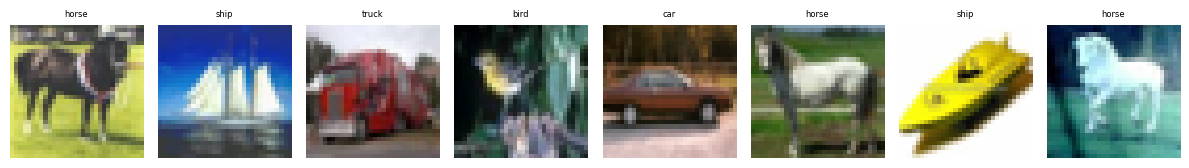

In [5]:
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2023, 0.1994, 0.2010)

# without augmentation
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# with horizontal + vertical flip
transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

full_base = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_base)
full_aug  = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_aug)
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

n_total = len(full_base)        # 50000
n_train = int(0.8 * n_total)   # 40000
n_val   = n_total - n_train    # 10000

gen = torch.Generator().manual_seed(42)
train_base, val_base = random_split(full_base, [n_train, n_val], generator=gen)
train_aug,  val_aug  = random_split(full_aug,  [n_train, n_val], generator=torch.Generator().manual_seed(42))

def make_loaders(train_set, val_set):
    tr = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    vl = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    te = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    return tr, vl, te

loaders = {
    'no_aug': make_loaders(train_base, val_base),
    'aug':    make_loaders(train_aug,  val_aug)
}

print(f'train={n_train}  val={n_val}  test={len(test_data)}')

imgs, labels = next(iter(loaders['no_aug'][0]))
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    img = imgs[i].permute(1,2,0).numpy()
    img = img * np.array(std) + np.array(mean)
    axes[i].imshow(np.clip(img, 0, 1))
    axes[i].set_title(class_names[labels[i]], fontsize=6)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

### Patch Embedding

In [6]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super(PatchEmbedding, self).__init__()
        self.num_patches = (img_size // patch_size) ** 2
        # use conv to split image into patches and project
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)           # (B, embed_dim, H/p, W/p)
        x = x.flatten(2)           # (B, embed_dim, num_patches)
        x = x.transpose(1, 2)     # (B, num_patches, embed_dim)
        return x

### Vision Transformer

In [7]:
class ViT(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3,
                 embed_dim=128, num_heads=4, num_layers=4, num_classes=10):
        super(ViT, self).__init__()

        self.patch_embed  = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches       = (img_size // patch_size) ** 2

        # learnable CLS token
        self.cls_token    = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # learnable positional encoding
        self.pos_embed    = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        encoder_layer     = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.1, batch_first=True
        )
        self.transformer  = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm         = nn.LayerNorm(embed_dim)

        # classification head
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes)
        )

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)

        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x   = x + self.pos_embed

        x   = self.transformer(x)
        x   = self.norm(x)
        # take CLS token output for classification
        out = self.head(x[:, 0])
        return out

### ResNet-18 Baseline

In [8]:
def get_resnet18():
    model = models.resnet18(weights=None)
    # adjust first conv for 32x32 input
    model.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc      = nn.Linear(512, NUM_CLASSES)
    return model

### Loss Functions - CE, Label Smoothing, Focal

In [9]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce   = nn.functional.cross_entropy(logits, targets, reduction='none')
        pt   = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()

def get_criterion(loss_type):
    if loss_type == 'ce':
        return nn.CrossEntropyLoss()
    elif loss_type == 'label_smooth':
        return nn.CrossEntropyLoss(label_smoothing=0.1)
    elif loss_type == 'focal':
        return FocalLoss(gamma=2.0)

### Optimizer Factory

In [10]:
def get_optimizer(model, name):
    if name == 'adam':
        return optim.Adam(model.parameters(), lr=1e-3)
    elif name == 'sgd':
        return optim.SGD(model.parameters(), lr=1e-2, momentum=0.9, weight_decay=5e-4)
    else:
        return optim.RMSprop(model.parameters(), lr=1e-3)

### Train and Eval Loops

In [11]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == y).sum().item()
        total      += y.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct    = 0
    total      = 0
    with torch.no_grad():
        for x, y in loader:
            x, y  = x.to(DEVICE), y.to(DEVICE)
            out   = model(x)
            loss  = criterion(out, y)
            total_loss += loss.item()
            correct    += (out.argmax(1) == y).sum().item()
            total      += y.size(0)
    return total_loss / len(loader), correct / total

### Main Experiment Runner

In [12]:
results       = {}
saved_models  = {}

def run_experiment(arch, loss_type, opt_name, aug_mode):
    name = f'{arch}_{loss_type}_{opt_name}_{aug_mode}'
    print(f'\nstarting: {name}')

    wandb.init(project=WANDB_PROJECT, name=name, config={
        'arch': arch, 'loss': loss_type,
        'optimizer': opt_name, 'augmentation': aug_mode, 'epochs': EPOCHS
    })

    train_loader, val_loader, test_loader = loaders[aug_mode]

    if arch == 'vit':
        model = ViT(
            img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_channels=3,
            embed_dim=EMBED_DIM, num_heads=NUM_HEADS,
            num_layers=NUM_LAYERS, num_classes=NUM_CLASSES
        ).to(DEVICE)
    else:
        model = get_resnet18().to(DEVICE)

    criterion = get_criterion(loss_type)
    optimizer = get_optimizer(model, opt_name)

    best_val_acc = 0

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), f'{name}_best.pt')

        wandb.log({
            'epoch': epoch,
            'train_loss': tr_loss, 'train_acc': tr_acc,
            'val_loss':   vl_loss, 'val_acc':   vl_acc
        })
        print(f'  epoch {epoch}/{EPOCHS}  train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}')

    # load best checkpoint and test
    model.load_state_dict(torch.load(f'{name}_best.pt'))
    te_loss, te_acc = evaluate(model, test_loader, criterion)
    print(f'  test_loss={te_loss:.4f}  test_acc={te_acc:.4f}')
    wandb.log({'test_loss': te_loss, 'test_acc': te_acc})

    results[name]      = {'test_acc': te_acc, 'test_loss': te_loss}
    saved_models[name] = model

    wandb.finish()
    return model

### Quick Test - run this first

In [13]:
run_experiment('vit',      'ce', 'adam', 'no_aug')
run_experiment('resnet18', 'ce', 'adam', 'no_aug')


starting: vit_ce_adam_no_aug


  epoch 1/10  train_loss=1.7714  train_acc=0.3335  val_loss=1.5955  val_acc=0.4176
  epoch 2/10  train_loss=1.4157  train_acc=0.4778  val_loss=1.2832  val_acc=0.5322
  epoch 3/10  train_loss=1.2293  train_acc=0.5546  val_loss=1.2072  val_acc=0.5609
  epoch 4/10  train_loss=1.1151  train_acc=0.5970  val_loss=1.1006  val_acc=0.6040
  epoch 5/10  train_loss=1.0298  train_acc=0.6301  val_loss=1.0295  val_acc=0.6361
  epoch 6/10  train_loss=0.9802  train_acc=0.6483  val_loss=1.0170  val_acc=0.6389
  epoch 7/10  train_loss=0.9246  train_acc=0.6676  val_loss=1.0208  val_acc=0.6393
  epoch 8/10  train_loss=0.8765  train_acc=0.6860  val_loss=0.9351  val_acc=0.6669
  epoch 9/10  train_loss=0.8492  train_acc=0.6966  val_loss=0.9893  val_acc=0.6572
  epoch 10/10  train_loss=0.8145  train_acc=0.7091  val_loss=0.9146  val_acc=0.6833
  test_loss=0.9351  test_acc=0.6766


epoch,▁▂▃▃▄▅▆▆▇█
test_acc,▁
test_loss,▁
train_acc,▁▄▅▆▇▇▇███
train_loss,█▅▄▃▃▂▂▁▁▁
val_acc,▁▄▅▆▇▇▇█▇█
val_loss,█▅▄▃▂▂▂▁▂▁
epoch,10
test_acc,0.6766
test_loss,0.93514
train_acc,0.70915



starting: resnet18_ce_adam_no_aug


  epoch 1/10  train_loss=1.2950  train_acc=0.5281  val_loss=1.0151  val_acc=0.6378
  epoch 2/10  train_loss=0.8009  train_acc=0.7159  val_loss=0.7610  val_acc=0.7268
  epoch 3/10  train_loss=0.5951  train_acc=0.7932  val_loss=0.6377  val_acc=0.7742
  epoch 4/10  train_loss=0.4599  train_acc=0.8395  val_loss=0.5838  val_acc=0.7978
  epoch 5/10  train_loss=0.3459  train_acc=0.8811  val_loss=0.6430  val_acc=0.7894
  epoch 6/10  train_loss=0.2544  train_acc=0.9105  val_loss=0.7562  val_acc=0.7729
  epoch 7/10  train_loss=0.1763  train_acc=0.9396  val_loss=0.6586  val_acc=0.8104
  epoch 8/10  train_loss=0.1331  train_acc=0.9540  val_loss=0.6953  val_acc=0.7977
  epoch 9/10  train_loss=0.0930  train_acc=0.9671  val_loss=0.8973  val_acc=0.7830
  epoch 10/10  train_loss=0.0792  train_acc=0.9711  val_loss=0.7798  val_acc=0.8056
  test_loss=0.6987  test_acc=0.8029


epoch,▁▂▃▃▄▅▆▆▇█
test_acc,▁
test_loss,▁
train_acc,▁▄▅▆▇▇████
train_loss,█▅▄▃▃▂▂▁▁▁
val_acc,▁▅▇▇▇▆█▇▇█
val_loss,█▄▂▁▂▄▂▃▆▄
epoch,10
test_acc,0.8029
test_loss,0.69875
train_acc,0.97113


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

### Full Grid - all combinations

In [ ]:
for arch in MODELS:
    for aug in AUG_MODES:
        for lf in LOSS_FNS:
            for opt in OPTIMIZERS:
                run_experiment(arch, lf, opt, aug)


starting: vit_ce_adam_no_aug


  epoch 1/10  train_loss=1.7655  train_acc=0.3357  val_loss=1.5187  val_acc=0.4286
  epoch 2/10  train_loss=1.4058  train_acc=0.4800  val_loss=1.2258  val_acc=0.5507
  epoch 3/10  train_loss=1.2336  train_acc=0.5509  val_loss=1.2066  val_acc=0.5562
  epoch 4/10  train_loss=1.1237  train_acc=0.5890  val_loss=1.1148  val_acc=0.5977
  epoch 5/10  train_loss=1.0438  train_acc=0.6246  val_loss=1.0690  val_acc=0.6207
  epoch 6/10  train_loss=0.9866  train_acc=0.6441  val_loss=0.9845  val_acc=0.6480
  epoch 7/10  train_loss=0.9354  train_acc=0.6639  val_loss=0.9612  val_acc=0.6584
  epoch 8/10  train_loss=0.8916  train_acc=0.6806  val_loss=0.9315  val_acc=0.6718
  epoch 9/10  train_loss=0.8489  train_acc=0.6951  val_loss=0.9304  val_acc=0.6774
  epoch 10/10  train_loss=0.8170  train_acc=0.7074  val_loss=0.9162  val_acc=0.6802
  test_loss=0.9348  test_acc=0.6665


epoch,▁▂▃▃▄▅▆▆▇█
test_acc,▁
test_loss,▁
train_acc,▁▄▅▆▆▇▇▇██
train_loss,█▅▄▃▃▂▂▂▁▁
val_acc,▁▄▅▆▆▇▇███
val_loss,█▅▄▃▃▂▂▁▁▁
epoch,10
test_acc,0.6665
test_loss,0.93484
train_acc,0.70737



starting: vit_ce_sgd_no_aug


  epoch 1/10  train_loss=1.9232  train_acc=0.2809  val_loss=1.7647  val_acc=0.3392
  epoch 2/10  train_loss=1.6920  train_acc=0.3679  val_loss=1.5797  val_acc=0.4203
  epoch 3/10  train_loss=1.5625  train_acc=0.4273  val_loss=1.5081  val_acc=0.4513
  epoch 4/10  train_loss=1.4444  train_acc=0.4704  val_loss=1.4128  val_acc=0.4889
  epoch 5/10  train_loss=1.3666  train_acc=0.5002  val_loss=1.3753  val_acc=0.5010
  epoch 6/10  train_loss=1.2958  train_acc=0.5303  val_loss=1.3139  val_acc=0.5205
  epoch 7/10  train_loss=1.2563  train_acc=0.5422  val_loss=1.2400  val_acc=0.5503
  epoch 8/10  train_loss=1.2086  train_acc=0.5559  val_loss=1.1914  val_acc=0.5714
  epoch 9/10  train_loss=1.1719  train_acc=0.5728  val_loss=1.2061  val_acc=0.5670
  epoch 10/10  train_loss=1.1379  train_acc=0.5854  val_loss=1.1145  val_acc=0.5953
  test_loss=1.1356  test_acc=0.5907


...


starting: resnet18_label_smooth_adam_no_aug


  epoch 1/10  train_loss=1.4890  train_acc=0.5473  val_loss=1.2856  val_acc=0.6459
  epoch 2/10  train_loss=1.1098  train_acc=0.7354  val_loss=1.1422  val_acc=0.7193
  epoch 3/10  train_loss=0.9500  train_acc=0.8151  val_loss=1.0225  val_acc=0.7751
  epoch 4/10  train_loss=0.8424  train_acc=0.8612  val_loss=1.0219  val_acc=0.7758
  epoch 5/10  train_loss=0.7502  train_acc=0.9012  val_loss=1.0475  val_acc=0.7670
  epoch 6/10  train_loss=0.6683  train_acc=0.9386  val_loss=0.9943  val_acc=0.7944
  epoch 7/10  train_loss=0.6056  train_acc=0.9667  val_loss=0.9940  val_acc=0.8039
  epoch 8/10  train_loss=0.5754  train_acc=0.9779  val_loss=1.0608  val_acc=0.7807
  epoch 9/10  train_loss=0.5588  train_acc=0.9835  val_loss=0.9814  val_acc=0.8072
  epoch 10/10  train_loss=0.5420  train_acc=0.9888  val_loss=0.9282  val_acc=0.8273
  test_loss=0.9436  test_acc=0.8245


epoch,▁▂▃▃▄▅▆▆▇█
test_acc,▁
test_loss,▁
train_acc,▁▄▅▆▇▇████
train_loss,█▅▄▃▃▂▁▁▁▁
val_acc,▁▄▆▆▆▇▇▆▇█
val_loss,█▅▃▃▃▂▂▄▂▁
epoch,10
test_acc,0.8245
test_loss,0.94357
train_acc,0.9888



starting: resnet18_label_smooth_sgd_no_aug


  epoch 1/10  train_loss=1.7056  train_acc=0.4386  val_loss=1.5215  val_acc=0.5418
  epoch 2/10  train_loss=1.3383  train_acc=0.6233  val_loss=1.3630  val_acc=0.6118
  epoch 3/10  train_loss=1.1376  train_acc=0.7294  val_loss=1.2439  val_acc=0.6731
  epoch 4/10  train_loss=0.9771  train_acc=0.8101  val_loss=1.1662  val_acc=0.7082
  epoch 5/10  train_loss=0.8136  train_acc=0.8972  val_loss=1.2656  val_acc=0.6918
  epoch 6/10  train_loss=0.6782  train_acc=0.9656  val_loss=1.2004  val_acc=0.7207
  epoch 7/10  train_loss=0.5948  train_acc=0.9953  val_loss=1.1411  val_acc=0.7402
  epoch 8/10  train_loss=0.5523  train_acc=0.9998  val_loss=1.1084  val_acc=0.7490


### Results Summary

In [ ]:
print(f'{"config":<50} {"test_acc":>10} {"test_loss":>10}')
print('-' * 72)
for k, v in sorted(results.items(), key=lambda x: -x[1]['test_acc']):
    print(f'{k:<50} {v["test_acc"]:>10.4f} {v["test_loss"]:>10.4f}')

best = max(results, key=lambda x: results[x]['test_acc'])
print(f'\nbest: {best}  acc={results[best]["test_acc"]:.4f}')

### Upload to HuggingFace

In [ ]:
create_repo(HF_REPO, exist_ok=True)
api = HfApi()

for name in saved_models.keys():
    fname = f'{name}_best.pt'
    if os.path.exists(fname):
        api.upload_file(
            path_or_fileobj=fname,
            path_in_repo=f'models/{fname}',
            repo_id=HF_REPO
        )
        print(f'uploaded: {fname}')

print(f'https://huggingface.co/{HF_REPO}')

In [ ]:
username = wandb.api.viewer()['entity']
print(f'W&B : https://wandb.ai/{username}/{WANDB_PROJECT}')
print(f'HF  : https://huggingface.co/{HF_REPO}')